In [ ]:
import pandas as pd
import zipfile
import requests
import io

# Download UCI Student Performance dataset
url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"

response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# See files inside the dataset
zip_file.namelist()

['.student.zip_old', 'student.zip']

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Load UCI Student Performance dataset
student_performance = fetch_ucirepo(id=320)

# Features and target
X = student_performance.data.features
y = student_performance.data.targets

# Combine into one dataframe
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
# Step 2: Understand The Dataset And Create Target

# Show the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Show all column names in the dataset
print("Columns:")
print(df.columns)

# Show the first 5 rows of the dataset
display(df.head())

# Show information about each column, such as data type and missing values
df.info()

# Show basic statistics for numeric columns
display(df.describe())

Dataset shape: (649, 33)
Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [ ]:
# Create a new column called "pass_fail"
# If final grade G3 is 10 or more, the student passed, so value is 1
# If final grade G3 is less than 10, the student failed, so value is 0
df["pass_fail"] = df["G3"].apply(lambda grade: 1 if grade >= 10 else 0)

# Count how many students passed and failed
print(df["pass_fail"].value_counts())

# Show the percentage of pass and fail students
print(df["pass_fail"].value_counts(normalize=True) * 100)

# Display the first 5 rows with G3 and pass_fail columns
display(df[["G3", "pass_fail"]].head())

pass_fail
1    549
0    100
Name: count, dtype: int64
pass_fail
1    84.59168
0    15.40832
Name: proportion, dtype: float64


,G3,pass_fail
0,11,1
1,11,1
2,12,1
3,14,1
4,13,1


In [ ]:
# Step 3: Data Cleaning And Preprocessing.

# Check how many missing values each column has
print(df.isnull().sum())

# Check the total number of missing values in the whole dataset
print("Total missing values:", df.isnull().sum().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
pass_fail     0
dtype: int64
Total missing values: 0


In [ ]:
# Create the target variable y
# This is what our model will try to predict: 1 means Pass, 0 means Fail
y = df["pass_fail"]

# Create the feature dataset X
# We remove "G3" because it is the final grade and was used to create pass_fail
# We also remove "pass_fail" because it is the answer/target column
X = df.drop(["G3", "pass_fail"], axis=1)

# Show the shape of X and y
# X contains the input columns, y contains the target result
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (649, 32)
y shape: (649,)


In [ ]:
# Convert categorical/text columns into numeric columns
# Example: school_GP, school_MS, sex_F, sex_M, etc.
X_encoded = pd.get_dummies(X, drop_first=True)

# Show the new shape after encoding
# The number of columns usually increases because text categories become separate numeric columns
print("Encoded X shape:", X_encoded.shape)

# Display the first 5 rows of the cleaned and encoded data
display(X_encoded.head())

Encoded X shape: (649, 41)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


In [ ]:
# Count how many students are in each class
# 1 means Pass, 0 means Fail
print(y.value_counts())

# Show target percentage
# This helps us understand if the dataset is balanced or imbalanced
print(y.value_counts(normalize=True) * 100)

pass_fail
1    549
0    100
Name: count, dtype: int64
pass_fail
1    84.59168
0    15.40832
Name: proportion, dtype: float64


In [ ]:
# Step 4: Split The Data Into Training And Testing Sets

# Import train_test_split to divide data into training and testing parts
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# X_encoded = input features
# y = target column, pass or fail
# test_size=0.2 means 20% data for testing and 80% for training
# random_state=42 makes the split same every time we run the code
# stratify=y keeps pass/fail ratio similar in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Show the shape of training feature data
print("X_train shape:", X_train.shape)

# Show the shape of testing feature data
print("X_test shape:", X_test.shape)

# Show the shape of training target data
print("y_train shape:", y_train.shape)

# Show the shape of testing target data
print("y_test shape:", y_test.shape)

X_train shape: (519, 41)
X_test shape: (130, 41)
y_train shape: (519,)
y_test shape: (130,)


In [ ]:
# Count pass/fail values in the training target data
print("Training target distribution:")
print(y_train.value_counts())

# Count pass/fail values in the testing target data
print("Testing target distribution:")
print(y_test.value_counts())

Training target distribution:
pass_fail
1    439
0     80
Name: count, dtype: int64
Testing target distribution:
pass_fail
1    110
0     20
Name: count, dtype: int64


In [ ]:
# Step 5: Train A Decision Tree Model

# Import the DecisionTreeClassifier model from scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree model
# random_state=42 makes the result reproducible
# max_depth=5 limits tree depth so the model does not become too complex
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the Decision Tree model using training data
# X_train contains the input features
# y_train contains the correct pass/fail answers
decision_tree.fit(X_train, y_train)

# Print a message after training is complete
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
# Use the trained model to predict pass/fail for the test data
y_pred = decision_tree.predict(X_test)

# Show the first 10 predicted values
print("First 10 predictions:", y_pred[:10])

# Show the first 10 actual values for comparison
print("First 10 actual values:", y_test.values[:10])

First 10 predictions: [1 1 1 1 1 0 1 1 1 1]
First 10 actual values: [1 1 1 1 1 0 0 1 1 1]


In [ ]:
# Step 6: Evaluate Model Performance

# Import accuracy_score to calculate the model accuracy
from sklearn.metrics import accuracy_score

# Import confusion_matrix to compare correct and wrong predictions
from sklearn.metrics import confusion_matrix

# Import classification_report to show precision, recall, and F1-score
from sklearn.metrics import classification_report

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy result
print("Decision Tree Accuracy:", accuracy)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.8846153846153846
Confusion Matrix:
[[ 12   8]
 [  7 103]]
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.60      0.62        20
           1       0.93      0.94      0.93       110

    accuracy                           0.88       130
   macro avg       0.78      0.77      0.77       130
weighted avg       0.88      0.88      0.88       130



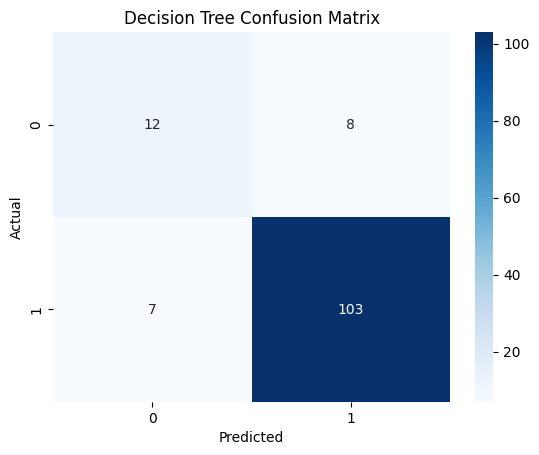

In [ ]:
# Import matplotlib for creating plots
import matplotlib.pyplot as plt

# Import seaborn for a nicer heatmap visualization
import seaborn as sns

# Create a heatmap for the confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Add title to the plot
plt.title("Decision Tree Confusion Matrix")

# Add label for x-axis
plt.xlabel("Predicted")

# Add label for y-axis
plt.ylabel("Actual")

# Show the plot
plt.show()

In [ ]:
# Step 7: Visualize Important Features

# Create a pandas Series for feature importance values
# decision_tree.feature_importances_ gives the importance score for each feature
# X_encoded.columns gives the names of the features
feature_importance = pd.Series(
    decision_tree.feature_importances_,
    index=X_encoded.columns
)

# Sort the feature importance values from highest to lowest
feature_importance = feature_importance.sort_values(ascending=False)

# Show the top 10 most important features
print("Top 10 important features:")
print(feature_importance.head(10))

Top 10 important features:
G2                   0.646557
G1                   0.125000
freetime             0.028066
goout                0.027496
reason_reputation    0.027402
studytime            0.025842
sex_M                0.023155
school_MS            0.020582
Fedu                 0.019460
famsize_LE3          0.016840
dtype: float64


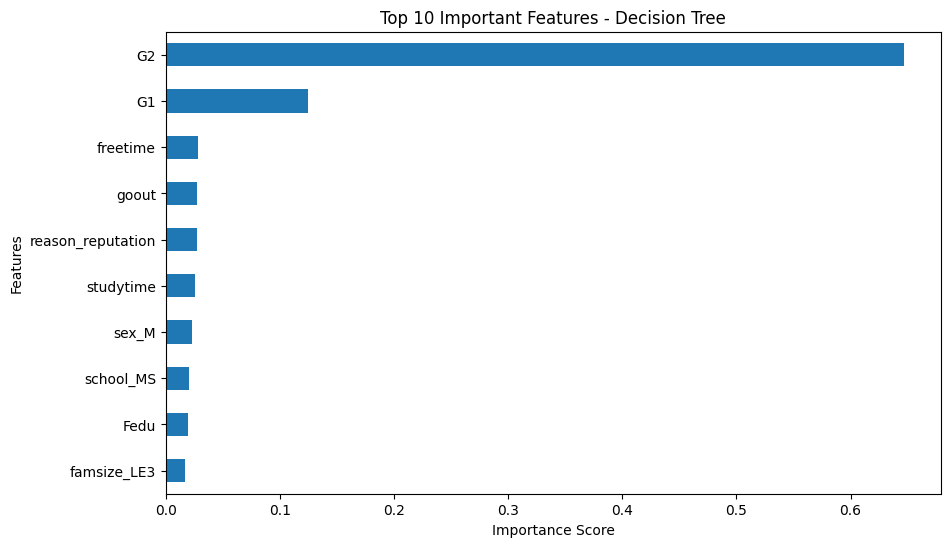

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Select the top 10 most important features
top_features = feature_importance.head(10)

# Set the figure size for the chart
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
top_features.sort_values().plot(kind="barh")

# Add a title to the chart
plt.title("Top 10 Important Features - Decision Tree")

# Add label for x-axis
plt.xlabel("Importance Score")

# Add label for y-axis
plt.ylabel("Features")

# Show the chart
plt.show()

In [ ]:
# Step 8: Train A Random Forest Model

# Import RandomForestClassifier from scikit-learn
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest model
# n_estimators=100 means the model will use 100 decision trees
# random_state=42 makes the result the same every time we run it
# max_depth=5 limits the depth of each tree to reduce overfitting
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

# Train the Random Forest model using the training data
# X_train contains the input features
# y_train contains the correct pass/fail labels
random_forest.fit(X_train, y_train)

# Use the trained Random Forest model to predict the test data
rf_pred = random_forest.predict(X_test)

# Print a success message
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Calculate Random Forest accuracy by comparing actual and predicted values
rf_accuracy = accuracy_score(y_test, rf_pred)

# Print the Random Forest accuracy
print("Random Forest Accuracy:", rf_accuracy)

# Create confusion matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)

# Print the confusion matrix
print("Random Forest Confusion Matrix:")
print(rf_cm)

# Print precision, recall, and F1-score for Random Forest
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9076923076923077
Random Forest Confusion Matrix:
[[ 13   7]
 [  5 105]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.94      0.95      0.95       110

    accuracy                           0.91       130
   macro avg       0.83      0.80      0.82       130
weighted avg       0.90      0.91      0.91       130



In [ ]:
# Print Decision Tree accuracy
print("Decision Tree Accuracy:", accuracy)

# Print Random Forest accuracy
print("Random Forest Accuracy:", rf_accuracy)

Decision Tree Accuracy: 0.8846153846153846
Random Forest Accuracy: 0.9076923076923077


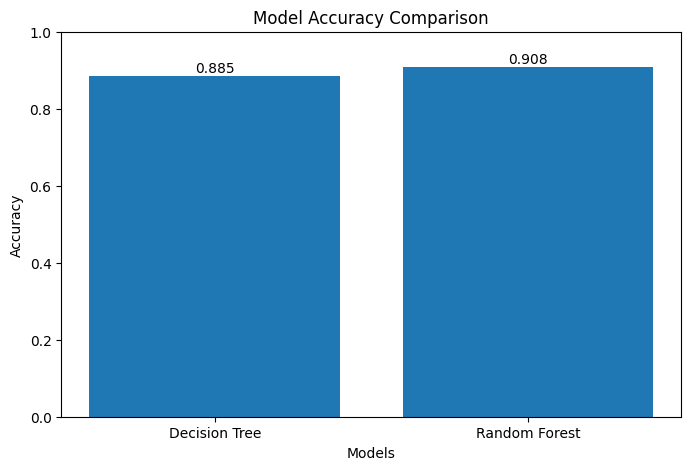

In [ ]:
# Step 9: Create Comparison Visualization

# Create a list with model names
model_names = ["Decision Tree", "Random Forest"]

# Create a list with model accuracy scores
model_accuracies = [accuracy, rf_accuracy]

# Set the figure size for the chart
plt.figure(figsize=(8, 5))

# Create a bar chart for model comparison
plt.bar(model_names, model_accuracies)

# Add a title to the chart
plt.title("Model Accuracy Comparison")

# Add label for x-axis
plt.xlabel("Models")

# Add label for y-axis
plt.ylabel("Accuracy")

# Set y-axis limit from 0 to 1 because accuracy is between 0 and 1
plt.ylim(0, 1)

# Show accuracy value on top of each bar
for index, value in enumerate(model_accuracies):
    # Place text slightly above each bar
    plt.text(index, value + 0.01, round(value, 3), ha="center")

# Show the chart
plt.show()